In [22]:
# ─── AJOUTER CE DICTIONNAIRE EN HAUT DU FICHIER ────────────
# Mapping basé sur l'ordre officiel IRCAM-Tifinagh
# Source : vérification visuelle des formes AMHCD

AMHCD_TO_UNICODE = {
    'ya'   : ('ⴰ', 'a'),
    'yab'  : ('ⴱ', 'b'),
    'yach' : ('ⵛ', 'c'),
    'yad'  : ('ⴷ', 'd'),
    'yadd' : ('ⴹ', 'ḍ'),
    'yae'  : ('ⴻ', 'e'),
    'yaf'  : ('ⴼ', 'f'),
    'yag'  : ('ⴳ', 'g'),
    'yagh' : ('ⵖ', 'ɣ'),
    'yagw' : ('ⴳⵯ','gʷ'),
    'yah'  : ('ⵀ', 'h'),
    'yahh' : ('ⵃ', 'ḥ'),
    'yaj'  : ('ⵊ', 'j'),
    'yak'  : ('ⴽ', 'k'),
    'yakw' : ('ⴽⵯ','kʷ'),
    'yal'  : ('ⵍ', 'l'),
    'yam'  : ('ⵎ', 'm'),
    'yan'  : ('ⵏ', 'n'),
    'yaq'  : ('ⵇ', 'q'),
    'yar'  : ('ⵔ', 'r'),
    'yarr' : ('ⵕ', 'ṛ'),
    'yas'  : ('ⵙ', 's'),
    'yass' : ('ⵚ', 'ṣ'),
    'yat'  : ('ⵜ', 't'),
    'yatt' : ('ⵟ', 'ṭ'),
    'yaw'  : ('ⵓ', 'u/w'),
    'yax'  : ('ⵅ', 'x'),
    'yay'  : ('ⵢ', 'y'),
    'yaz'  : ('ⵣ', 'z'),
    'yazz' : ('ⵥ', 'ẓ'),
    'yey'  : ('ⴻ', 'ə'),
    'yi'   : ('ⵉ', 'i'),
    'yu'   : ('ⵓ', 'u'),
}

C:\Users\fatima zehra\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\fatima zehra\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\fatima zehra\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_

Modèle chargé.
Classes (33) : [np.str_('ya'), np.str_('yab'), np.str_('yach'), np.str_('yad'), np.str_('yadd'), np.str_('yae'), np.str_('yaf'), np.str_('yag'), np.str_('yagh'), np.str_('yagw'), np.str_('yah'), np.str_('yahh'), np.str_('yaj'), np.str_('yak'), np.str_('yakw'), np.str_('yal'), np.str_('yam'), np.str_('yan'), np.str_('yaq'), np.str_('yar'), np.str_('yarr'), np.str_('yas'), np.str_('yass'), np.str_('yat'), np.str_('yatt'), np.str_('yaw'), np.str_('yax'), np.str_('yay'), np.str_('yaz'), np.str_('yazz'), np.str_('yey'), np.str_('yi'), np.str_('yu')]
  Image inversée (fond blanc détecté)


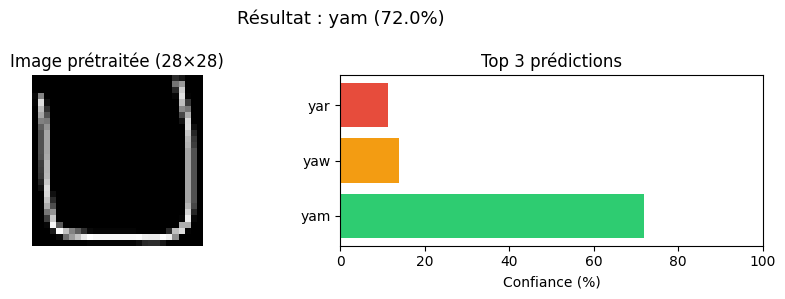


 Classe reconnue : yam
   Confiance       : 72.02%

 Top 3 :
   yam    → 72.02%
   yaw    → 13.95%
   yar    → 11.33%


In [1]:
from tensorflow.keras.models import load_model
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt
import os

# ─── 1. CHARGEMENT DU MODÈLE ET DES CLASSES ───────────────
model       = load_model("../results/models/best_model.h5")
class_names = list(np.load("../data/class_names.npy"))

print(f"Modèle chargé.")
print(f"Classes ({len(class_names)}) : {class_names}")


# ─── 2. FONCTION DE PRÉDICTION ────────────────────────────
def predire_nouvelle_image(image_path):
    """
    Prédit la classe AMHCD d'une image extérieure au dataset.
    Gère automatiquement : fond blanc/noir, taille quelconque.
    """
    if not os.path.exists(image_path):
        print(f" Fichier introuvable : {image_path}")
        return None

    # Chargement et conversion en niveaux de gris
    img = Image.open(image_path).convert("L")

    # Si le fond est blanc (pixel moyen > 127) → on inverse
    img_array_check = np.array(img)
    if img_array_check.mean() > 127:
        img = ImageOps.invert(img)
        print("  Image inversée (fond blanc détecté)")

    # Redimensionnement en 28x28
    img = img.resize((28, 28))
    img_array = np.array(img) / 255.0
    img_input = img_array.reshape(1, 28, 28, 1)

    # Prédiction
    prediction = model.predict(img_input, verbose=0)
    top3_indices = np.argsort(prediction[0])[::-1][:3]

    # Affichage
    fig, axes = plt.subplots(1, 2, figsize=(9, 3))

    axes[0].imshow(img_array, cmap='gray')
    axes[0].set_title("Image prétraitée (28×28)")
    axes[0].axis('off')

    chars  = [class_names[i] for i in top3_indices]
    scores = [prediction[0][i] * 100 for i in top3_indices]
    colors = ['#2ecc71', '#f39c12', '#e74c3c']
    axes[1].barh(chars, scores, color=colors)
    axes[1].set_xlabel("Confiance (%)")
    axes[1].set_title("Top 3 prédictions")
    axes[1].set_xlim(0, 100)

    plt.suptitle(f"Résultat : {class_names[top3_indices[0]]} ({scores[0]:.1f}%)", fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f"\n Classe reconnue : {class_names[top3_indices[0]]}")
    print(f"   Confiance       : {scores[0]:.2f}%")
    print(f"\n Top 3 :")
    for i in top3_indices:
        print(f"   {class_names[i]:6s} → {prediction[0][i]*100:.2f}%")

    return class_names[top3_indices[0]]


# ─── 3. TEST AVEC UNE IMAGE DU DATASET AMHCD ──────────────
# Copie une vraie image AMHCD pour vérifier que le modèle fonctionne
import shutil, glob


# ─── 4. TESTE AVEC TA PROPRE IMAGE ────────────────────────
predire_nouvelle_image("../test/image4.png")  # Remplace par le chemin de ton image


# ─── 5. TEST SUR PLUSIEURS IMAGES EN BATCH ────────────────
def tester_batch(dossier_test):
    """
    Teste toutes les images d'un dossier et affiche un résumé.
    Structure attendue : dossier_test/nom_classe/image.png
    """
    resultats = []
    for classe in sorted(os.listdir(dossier_test)):
        dossier_classe = os.path.join(dossier_test, classe)
        if not os.path.isdir(dossier_classe):
            continue
        for img_file in os.listdir(dossier_classe):
            img_path = os.path.join(dossier_classe, img_file)
            img      = Image.open(img_path).convert("L").resize((28, 28))
            arr      = np.array(img) / 255.0
            pred     = model.predict(arr.reshape(1, 28, 28, 1), verbose=0)
            predicted = class_names[np.argmax(pred)]
            resultats.append({'vraie': classe, 'predite': predicted, 'ok': predicted == classe})

    if resultats:
        acc = sum(r['ok'] for r in resultats) / len(resultats) * 100
        print(f"\nBatch accuracy : {acc:.2f}% sur {len(resultats)} images")
    return resultats

# Pour tester un dossier entier :
# tester_batch("../test/mon_dossier")

✓ Fichier trouvé : ../test/image9.png


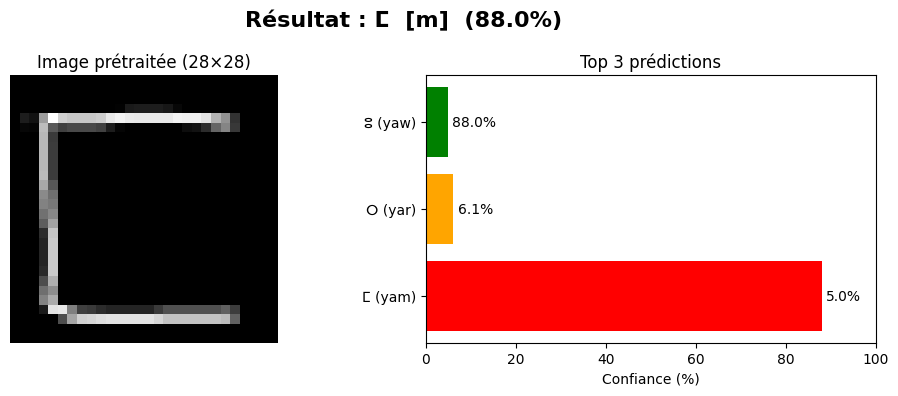


  Caractère Tifinagh : ⵎ
  Translittération   : m
  Label AMHCD        : yam
  Confiance          : 87.97%

  Top 3 :
    1. ⵎ [m] (yam) → 87.97%
    2. ⵔ [r] (yar) → 6.10%
    3. ⵓ [u/w] (yaw) → 4.95%



In [51]:
import os

image_path = "../test/image9.png"

# Vérification avant d'appeler
if not os.path.exists(image_path):
    print(f" Fichier introuvable : {image_path}")
    print(f"   Dossier actuel : {os.getcwd()}")
    print(f"   Fichiers dans test/ :")
    if os.path.exists("test"):
        for f in os.listdir("test"):
            print(f"     - {f}")
    else:
        print("     Dossier test/ n'existe pas")
else:
    print(f"✓ Fichier trouvé : {image_path}")
    # ── Appel de la fonction ──────────────────────────────────
    label, unicode_char, confiance = afficher_resultat(
        image_path, model, class_names
    )


Trouvé : 780 images pour 'yatt'


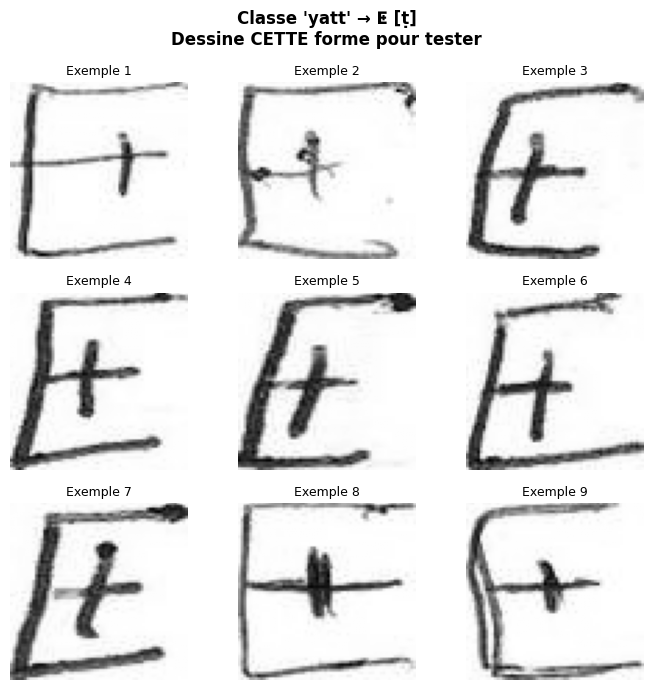

In [43]:
import matplotlib.pyplot as plt
import glob, os
from PIL import Image
import numpy as np

AMHCD_PATH = "../data/AMHCD_64/AMHCD_64"
classe = "yatt"

# ── Correction : chercher .jpeg directement ──────────────────
imgs = glob.glob(os.path.join(AMHCD_PATH, classe, "*.jpeg"))
imgs += glob.glob(os.path.join(AMHCD_PATH, classe, "*.jpg"))
imgs += glob.glob(os.path.join(AMHCD_PATH, classe, "*.png"))
imgs = sorted(imgs)

print(f"Trouvé : {len(imgs)} images pour '{classe}'")

# ── Afficher 9 exemples ──────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(7, 7))
axes = axes.flatten()

for i in range(min(9, len(imgs))):
    img = np.array(Image.open(imgs[i]).convert("L"))
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Exemple {i+1}", fontsize=9)
    axes[i].axis('off')

for j in range(i+1, 9):
    axes[j].axis('off')

uni, tr = AMHCD_TO_UNICODE[classe]
plt.suptitle(f"Classe '{classe}' → {uni} [{tr}]\nDessine CETTE forme pour tester",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()